## Vehicle Count Prediction using x in Scikit-Learn

### 1. Importing Libraries

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns

### 2. Loading Dataset

In [2]:
url = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/57-Vehicle%20Count%20Prediction/vehicles.csv"

In [3]:
df = pd.read_csv(url)
df.head()

,DateTime,Vehicles
0,2015-11-01 00:00:00,15
1,2015-11-01 01:00:00,13
2,2015-11-01 02:00:00,10
3,2015-11-01 03:00:00,7
4,2015-11-01 04:00:00,9


### 3. Data Preprocessing

In [4]:
df.shape

(48120, 2)

In [5]:
df.describe()

,Vehicles
count,48120.000000
mean,22.791334
std,20.750063
min,1.000000
25%,9.000000
50%,15.000000
75%,29.000000
max,180.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Vehicles  48120 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 752.0+ KB


In [7]:
df.isnull().sum()

,0
DateTime,0
Vehicles,0


In [8]:
df.head()

,DateTime,Vehicles
0,2015-11-01 00:00:00,15
1,2015-11-01 01:00:00,13
2,2015-11-01 02:00:00,10
3,2015-11-01 03:00:00,7
4,2015-11-01 04:00:00,9


In [9]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [24]:
df['day'] = df['DateTime'].dt.day
df['weekday'] = df['DateTime'].dt.weekday
df['hour'] = df['DateTime'].dt.hour
df['month'] = df['DateTime'].dt.month
df['year'] = df['DateTime'].dt.year
df['dayofyear'] = df['DateTime'].dt.dayofyear
df['weekofyear'] = df['DateTime'].dt.isocalendar().week

In [25]:
df.head()

,DateTime,Vehicles,date,weekday,hour,month,year,dayofyear,weekofyear,day
0,2015-11-01 00:00:00,15,1,6,0,11,2015,305,44,1
1,2015-11-01 01:00:00,13,1,6,1,11,2015,305,44,1
2,2015-11-01 02:00:00,10,1,6,2,11,2015,305,44,1
3,2015-11-01 03:00:00,7,1,6,3,11,2015,305,44,1
4,2015-11-01 04:00:00,9,1,6,4,11,2015,305,44,1


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DateTime    48120 non-null  datetime64[ns]
 1   Vehicles    48120 non-null  int64         
 2   date        48120 non-null  int32         
 3   weekday     48120 non-null  int32         
 4   hour        48120 non-null  int32         
 5   month       48120 non-null  int32         
 6   year        48120 non-null  int32         
 7   dayofyear   48120 non-null  int32         
 8   weekofyear  48120 non-null  UInt32        
 9   day         48120 non-null  int32         
dtypes: UInt32(1), datetime64[ns](1), int32(7), int64(1)
memory usage: 2.2 MB


In [27]:
df = df.drop(['DateTime'], axis=1)

In [28]:
X = df.drop(['Vehicles'], axis=1)
y = df['Vehicles']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 4. Build and Fit the Model

In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

### 5. Make Prediction

In [31]:
y_pred = model.predict(X_test)

In [34]:
for i in range(5):
    print(f"Actual: {y_test.iloc[i]}             Predicted: {y_pred[i]}")

Actual: 9             Predicted: 22.86757142857143
Actual: 97             Predicted: 31.729166666666664
Actual: 13             Predicted: 24.398000000000003
Actual: 11             Predicted: 9.178833333333332
Actual: 24             Predicted: 18.4825


In [40]:
model.predict([[11,6,0,1,2015,11,2, 1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([8.66257143])

### 6. Evaluate the Model

In [36]:
train_r2 = model.score(X_train, y_train)
train_r2

0.29930845082797564

In [37]:
test_r2 = model.score(X_test, y_test)
test_r2

-0.47432410802242986

In [38]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_pred)

600.8559897361102

### 7. Plot Evaluation Metrics

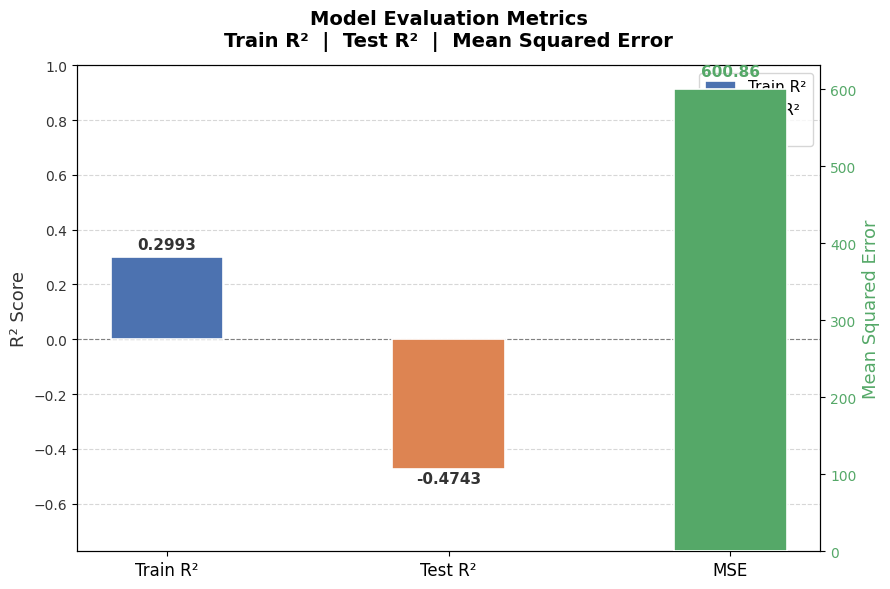

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# Compute metrics
train_r2 = model.score(X_train, y_train)
test_r2  = model.score(X_test,  y_test)
mse      = mean_squared_error(y_test, y_pred)

fig, ax1 = plt.subplots(figsize=(9, 6))

# ── R² bars (left axis) ─────────────────────────────────────────────────
r2_labels  = ['Train R²', 'Test R²']
r2_values  = [train_r2, test_r2]
r2_colors  = ['#4C72B0', '#DD8452']
x_r2       = np.array([0, 1])

bars_r2 = ax1.bar(x_r2, r2_values, width=0.4,
                  color=r2_colors, edgecolor='white', linewidth=1.2,
                  label='R² Score', zorder=3)

ax1.set_ylabel('R² Score', fontsize=13, color='#333333')
ax1.set_ylim(min(r2_values) - 0.3, 1.0)
ax1.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax1.tick_params(axis='y', labelcolor='#333333')

# ── MSE bar (right axis) ────────────────────────────────────────────────
ax2 = ax1.twinx()
x_mse = np.array([2])
bars_mse = ax2.bar(x_mse, [mse], width=0.4,
                   color='#55A868', edgecolor='white', linewidth=1.2,
                   label='MSE', zorder=3)

ax2.set_ylabel('Mean Squared Error', fontsize=13, color='#55A868')
ax2.tick_params(axis='y', labelcolor='#55A868')

# ── Annotations ─────────────────────────────────────────────────────────
for bar, val in zip(bars_r2, r2_values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             val + (0.02 if val >= 0 else -0.06),
             f'{val:.4f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='#333333')

for bar, val in zip(bars_mse, [mse]):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             val + mse * 0.02,
             f'{val:.2f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='#55A868')

# ── Labels & Legend ─────────────────────────────────────────────────────
all_bars   = [bars_r2[0], bars_r2[1], bars_mse[0]]
all_labels = ['Train R²', 'Test R²', 'MSE']
ax1.legend(all_bars, all_labels, loc='upper right', fontsize=11)

ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(['Train R²', 'Test R²', 'MSE'], fontsize=12)
ax1.set_title('Model Evaluation Metrics\nTrain R²  |  Test R²  |  Mean Squared Error',
              fontsize=14, fontweight='bold', pad=14)

ax1.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
fig.tight_layout()
plt.show()